# Titanic Survival Analysis

Exploratory Data Analysis (EDA) on the Titanic dataset to understand what factors — class, gender, age, family size, fare, port of embarkation — influenced whether a passenger survived.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (891, 12)


In [6]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Check and Handle Missing Values

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Age: fill missing with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: fill missing with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: too many missing values to fill meaningfully, drop the column
df.drop("Cabin", axis=1, inplace=True, errors="ignore")

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 4. Overall Survival Rate

In [14]:
survival_counts = df["Survived"].value_counts()
survival_rate = df["Survived"].mean() * 100

print("Did not survive:", survival_counts[0])
print("Survived:", survival_counts[1])
print("Overall Survival Rate: {:.2f}%".format(survival_rate))

Did not survive: 549
Survived: 342
Overall Survival Rate: 38.38%


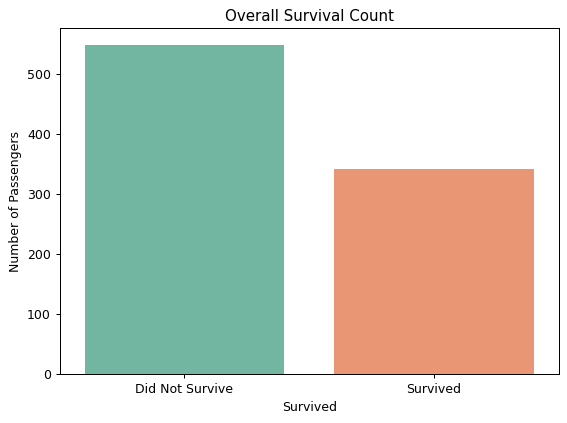

In [15]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="Survived", hue="Survived", palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_title("Overall Survival Count")
ax.set_ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

## 5. Survival by Passenger Class

In [17]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [18]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

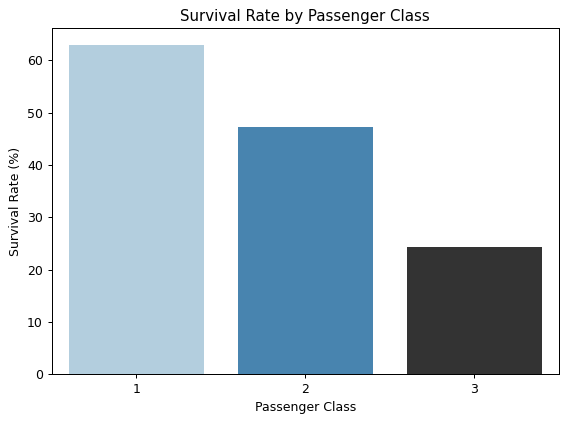

In [19]:
fig, ax = plt.subplots()
sns.barplot(x=class_survival.index, y=class_survival.values, hue=class_survival.index,
            palette="Blues_d", legend=False, ax=ax)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

## 6. Survival by Gender

In [21]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [22]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

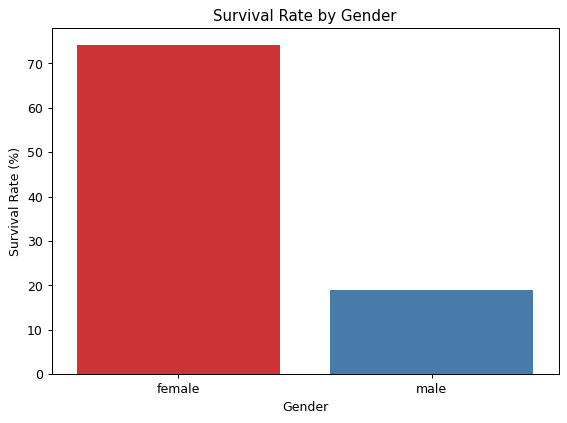

In [23]:
fig, ax = plt.subplots()
sns.barplot(x=gender_survival.index, y=gender_survival.values, hue=gender_survival.index,
            palette="Set1", legend=False, ax=ax)
ax.set_title("Survival Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

## 7. Survival by Gender AND Class Combined

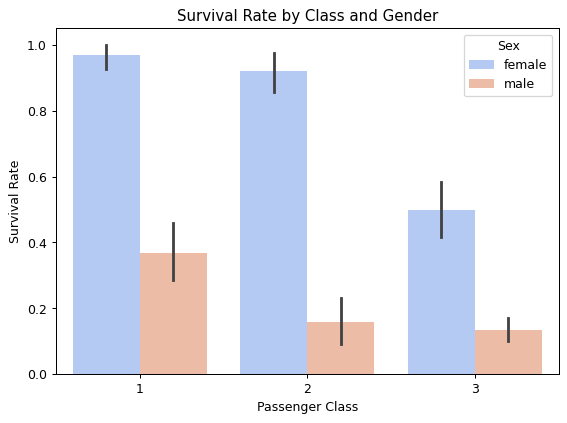

In [25]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", palette="coolwarm", ax=ax)
ax.set_title("Survival Rate by Class and Gender")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()

## 8. Age Distribution

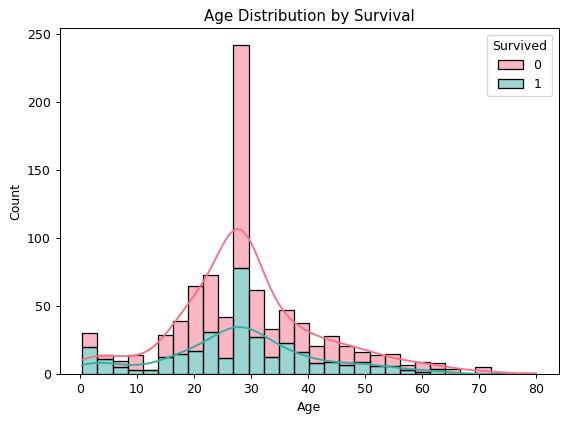

In [27]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, palette="husl", multiple="stack", ax=ax)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
plt.tight_layout()
plt.show()

## 9. Survival by Age Group

In [29]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-35)", "Adult (36-60)", "Senior (60+)"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_survival = df.groupby("Age_Group", observed=True)["Survived"].mean() * 100
age_group_survival

Age_Group
Child (0-12)           57.971014
Teen (13-18)           42.857143
Young Adult (19-35)    35.327103
Adult (36-60)          40.000000
Senior (60+)           22.727273
Name: Survived, dtype: float64

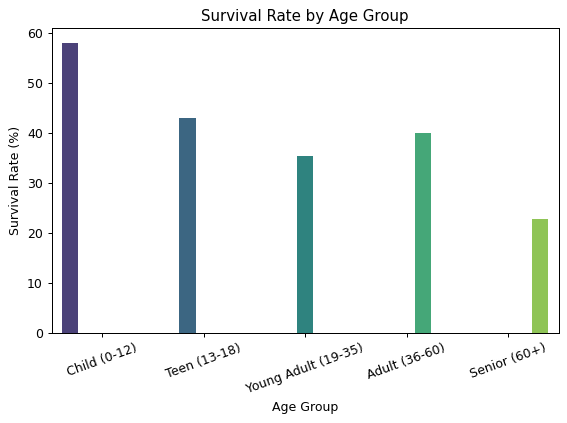

In [30]:
fig, ax = plt.subplots()
sns.barplot(x=age_group_survival.index, y=age_group_survival.values, hue=age_group_survival.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Survival Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Survival Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Family Size and Survival

Combining `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) into a single family size feature.

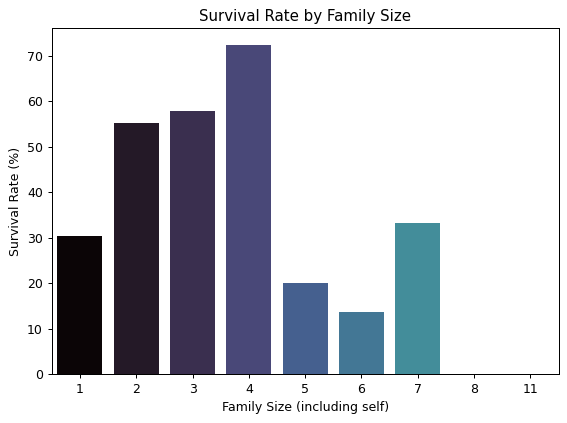

In [32]:
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("Family_Size")["Survived"].mean() * 100

fig, ax = plt.subplots()
sns.barplot(x=family_survival.index, y=family_survival.values, hue=family_survival.index,
            palette="mako", legend=False, ax=ax)
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("Family Size (including self)")
ax.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

## 11. Fare and Survival

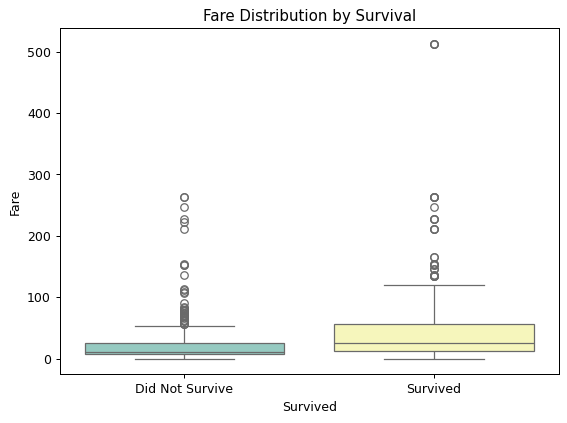

In [34]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Survived", y="Fare", hue="Survived", palette="Set3", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_title("Fare Distribution by Survival")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

## 12. Survival by Port of Embarkation

In [36]:
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100
embarked_survival

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

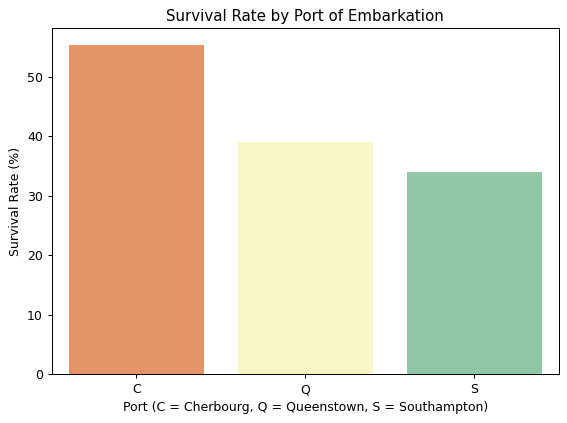

In [37]:
fig, ax = plt.subplots()
sns.barplot(x=embarked_survival.index, y=embarked_survival.values, hue=embarked_survival.index,
            palette="Spectral", legend=False, ax=ax)
ax.set_title("Survival Rate by Port of Embarkation")
ax.set_xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
ax.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

## 13. Correlation Heatmap of Numeric Features

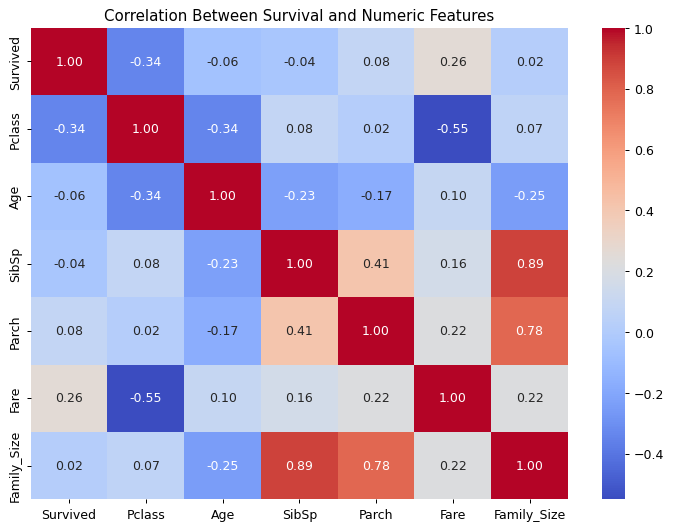

In [39]:
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Family_Size"]]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between Survival and Numeric Features")
plt.tight_layout()
plt.show()

## 14. Key Insights

- **Gender was the single biggest factor** — women survived at a much higher rate than men ("women and children first").
- **Passenger class mattered a lot** — 1st class passengers had the highest survival rate, 3rd class the lowest, reflecting cabin location and lifeboat access.
- **Combining class and gender** shows the effect compounds: 1st class women had the highest survival rate of any group, while 3rd class men had the lowest.
- **Children had a survival advantage** over adults, consistent with priority boarding for children.
- **Passengers who paid higher fares** (usually correlated with class) were more likely to survive.
- **Very large families (5+ members) and solo travelers** had lower survival rates than small families (2-4 members), possibly because large groups struggled to stay together and solo travelers had less help getting to lifeboats.
- **Port of embarkation** shows some difference in survival rate, but this is likely confounded with passenger class distribution at each port rather than being a direct cause.
